# Brazil E-Commerce — Customer Analysis

Analysis of the **Olist `olist_customers_dataset.csv`** file.

Columns:
- `customer_id` — key to the orders dataset (one per order)
- `customer_unique_id` — stable identifier for a real customer across orders
- `customer_zip_code_prefix` — first 5 digits of the zip code
- `customer_city` — city name
- `customer_state` — 2-letter state code

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
cust = pd.read_csv(
    "Data/olist_customers_dataset.csv",
    dtype={"customer_zip_code_prefix": str},
)
print(f"Shape: {cust.shape[0]:,} rows x {cust.shape[1]} columns")
cust.head()

Shape: 99,441 rows x 5 columns


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
cust.info()
cust.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441,99441,99441
unique,99441,96096,14994,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,22790,sao paulo,SP
freq,1,17,142,15540,41746


## 2. Data quality checks

In [4]:
print("Missing values per column:")
print(cust.isna().sum())

dup = cust.duplicated().sum()
print(f"\nFully duplicated rows: {dup:,} ({dup / len(cust):.1%})")

dup_cid = cust["customer_id"].duplicated().sum()
print(f"Duplicated customer_id: {dup_cid:,} (should be 0 — one per order)")

Missing values per column:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Fully duplicated rows: 0 (0.0%)
Duplicated customer_id: 0 (should be 0 — one per order)


#### **Atharva Thought**

- Compare the National Order Avg. value with state avg order value.
- Compared the customer location with population density
- Highest value 

## 3. Unique customers vs. orders

`customer_id` is unique per order, while `customer_unique_id` identifies the real person.
The gap between the two counts tells us how many customers placed more than one order.

In [5]:
n_rows = len(cust)
n_unique = cust["customer_unique_id"].nunique()
print(f"Rows (customer_id / orders): {n_rows:,}")
print(f"Distinct customers (customer_unique_id): {n_unique:,}")
print(f"Repeat-order rows: {n_rows - n_unique:,} ({(n_rows - n_unique) / n_rows:.1%})")

orders_per_customer = cust["customer_unique_id"].value_counts()
repeat_customers = (orders_per_customer > 1).sum()
print(f"Customers with >1 order: {repeat_customers:,} ({repeat_customers / n_unique:.1%})")
orders_per_customer.head(10)

Rows (customer_id / orders): 99,441
Distinct customers (customer_unique_id): 96,096
Repeat-order rows: 3,345 (3.4%)
Customers with >1 order: 2,997 (3.1%)


customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
63cfc61cee11cbe306bff5857d00bfe4     6
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
de34b16117594161a6a89c50b289d35a     6
dc813062e0fc23409cd255f7f53c7074     6
Name: count, dtype: int64

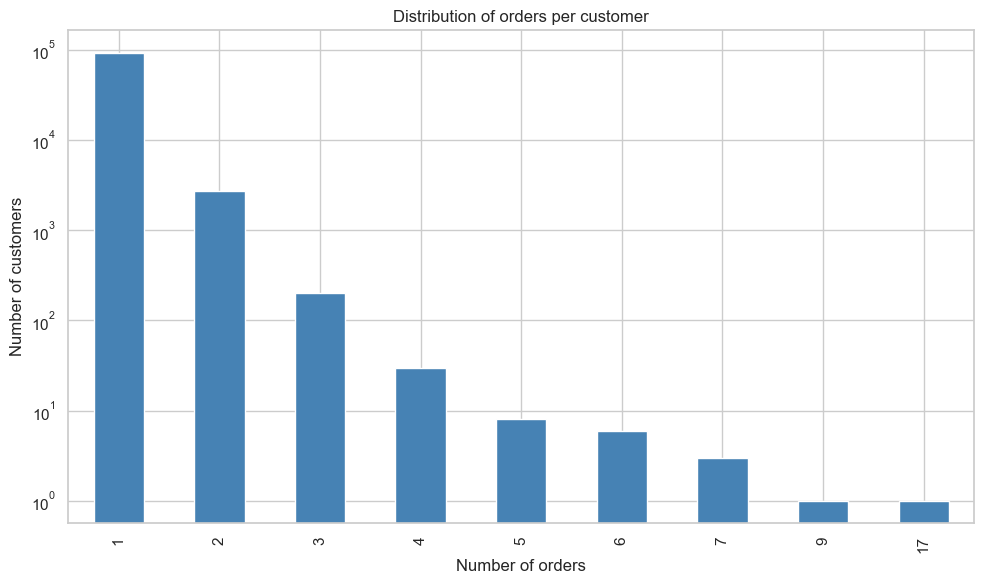

In [6]:
dist = orders_per_customer.value_counts().sort_index()
ax = dist.head(10).plot(kind="bar", color="steelblue")
ax.set_title("Distribution of orders per customer")
ax.set_xlabel("Number of orders")
ax.set_ylabel("Number of customers")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 4. Customers by state

Distinct states: 27


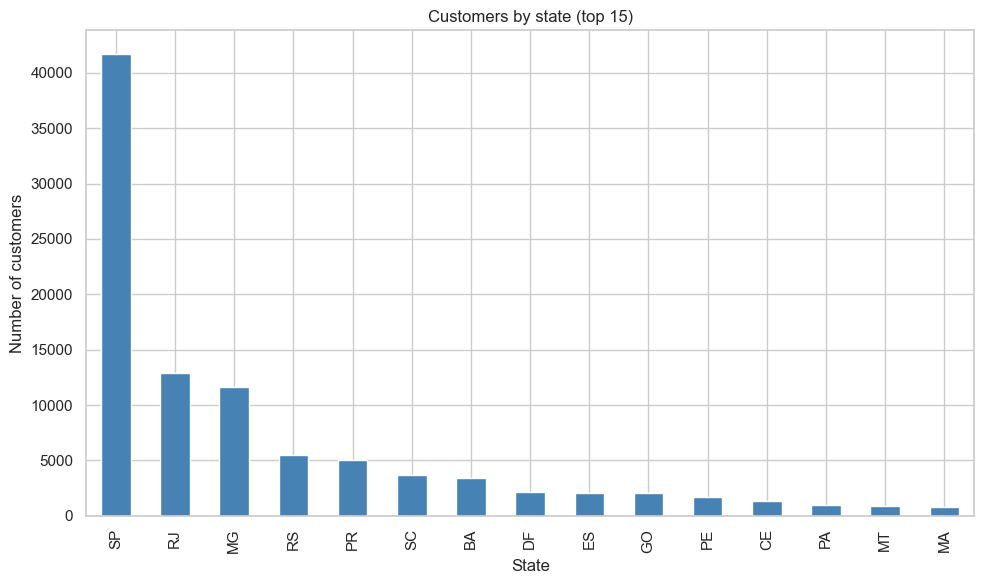

In [7]:
by_state = cust["customer_state"].value_counts()
print(f"Distinct states: {by_state.shape[0]}")

ax = by_state.head(15).plot(kind="bar", color="steelblue")
ax.set_title("Customers by state (top 15)")
ax.set_xlabel("State")
ax.set_ylabel("Number of customers")
plt.tight_layout()
plt.show()

## 5. Customers by city

Distinct city names: 4,119


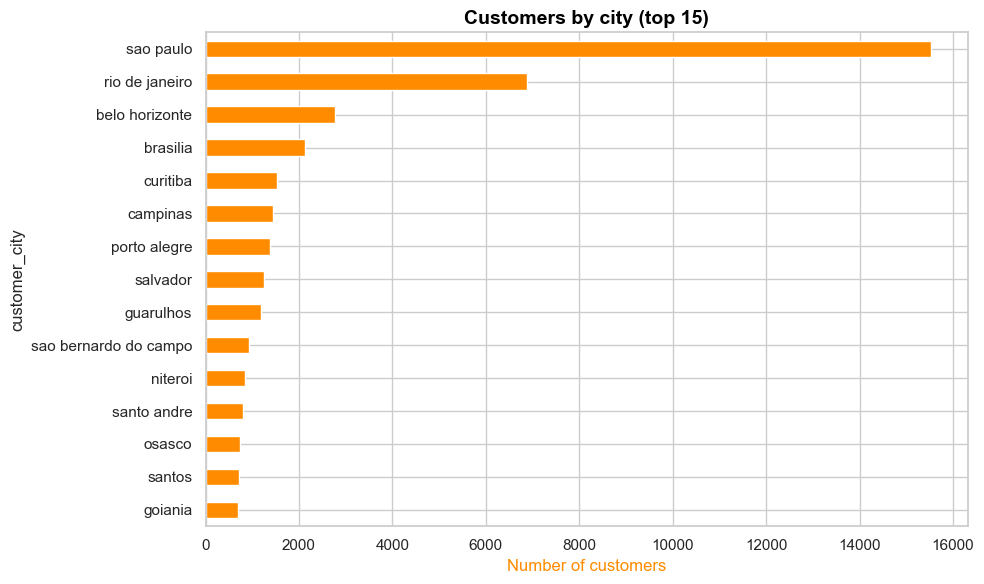

In [8]:
by_city = cust["customer_city"].value_counts()
print(f"Distinct city names: {by_city.shape[0]:,}")

ax = by_city.head(15).plot(kind="barh", color="darkorange")
ax.invert_yaxis()
ax.set_title("Customers by city (top 15)", color="black", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of customers", color="darkorange")
plt.tight_layout()
plt.show()

## 6. State-level summary table

In [9]:
state_summary = (
    cust.groupby("customer_state")
    .agg(
        orders=("customer_id", "size"),
        unique_customers=("customer_unique_id", "nunique"),
        cities=("customer_city", "nunique"),
        zip_prefixes=("customer_zip_code_prefix", "nunique"),
    )
    .sort_values("orders", ascending=False)
)
state_summary["orders_per_customer"] = (
    state_summary["orders"] / state_summary["unique_customers"]
).round(3)
state_summary

,orders,unique_customers,cities,zip_prefixes,orders_per_customer
customer_state,,,,,
SP,41746,40302,629,5591,1.036
RJ,12852,12384,149,1199,1.038
MG,11635,11259,745,1349,1.033
RS,5466,5277,379,877,1.036
PR,5045,4882,364,861,1.033
SC,3637,3534,240,517,1.029
BA,3380,3277,353,735,1.031
DF,2140,2075,6,465,1.031
ES,2033,1964,95,265,1.035


## 7. Share of customers — top 10 states

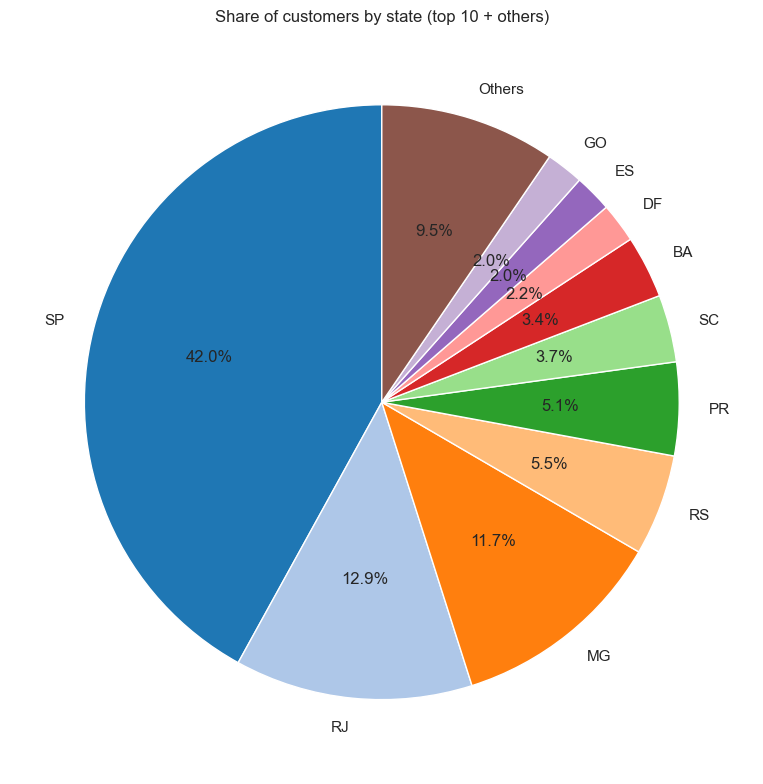

In [10]:
top10 = by_state.head(10)
others = by_state.iloc[10:].sum()
shares = pd.concat([top10, pd.Series({"Others": others})])

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(shares.values, labels=shares.index, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("tab20", len(shares)))
ax.set_title("Share of customers by state (top 10 + others)")
plt.tight_layout()
plt.show()

## 8. Key takeaways

_Fill in after running the cells above. Typical findings for this dataset:_

- The customer base is heavily concentrated in the Southeast (SP, RJ, MG), mirroring the geolocation coverage.
- Almost every `customer_unique_id` has a single order — repeat purchasing is rare, so this is largely a one-shot customer base.
- `customer_id` is order-grained; join on `customer_unique_id` for true per-person analysis.